**Ejercicio 1**
Describir las funciones de la librería Scikit-learn que permiten hacer uso de las métricas de evaluación (MSE, RMSE, R cuadrado, MAE y RMSLE)

In [19]:
y_true = [3, 5, 2.5, 7]
y_pred = [2.5, 0.0, 2, 8]

In [20]:
# Declaración de las librearías y módulos necesarios
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_log_error
#from sklearn.metrics import root_mean_squared_error
import numpy as np

In [21]:
print(mean_squared_error(y_true, y_pred))
# root_mean_squared_error(y_true, y_pred)
print(np.sqrt(mean_squared_error(y_true, y_pred)))
print(r2_score(y_true, y_pred))
print(mean_absolute_error(y_true, y_pred))
print(mean_squared_log_error(y_true, y_pred))

6.625
2.57390753524675
-1.0886699507389164
1.75
0.8164669759910711


**Ejercicio 2**
modelo de regresión lineal para la predicción del precio de vivienda.

In [22]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
housing = fetch_california_housing(as_frame=True)
housing = housing.frame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
#Normalización
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame


scaler = MinMaxScaler()
scaler.fit(housing)
datos = pd.DataFrame(scaler.transform(housing), columns = housing.columns)

In [25]:
X = datos.iloc[:,:-1]
y = datos.iloc[:,-1]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Creamos un objeto de Regresion lineal
from sklearn import linear_model

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [28]:
regr.coef_


array([ 1.34141218,  0.10225466, -3.58686211,  5.44700603, -0.01493083,
       -0.90349071, -0.81448062, -0.8978167 ])

In [29]:
regr.intercept_

0.7188733033299477

In [30]:
y_pred = regr.predict(X_test)

In [31]:
y_pred

array([0.11734649, 0.33278761, 0.52776459, ..., 0.89046647, 0.21392101,
       0.38338244])

In [ ]:
y_pred_desnorm=scaler.inverse_transform(y_pred)

In [32]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,y_pred)
print('Baseline RMSE of model:', rmse)

Baseline RMSE of model: 0.15372748628104133


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


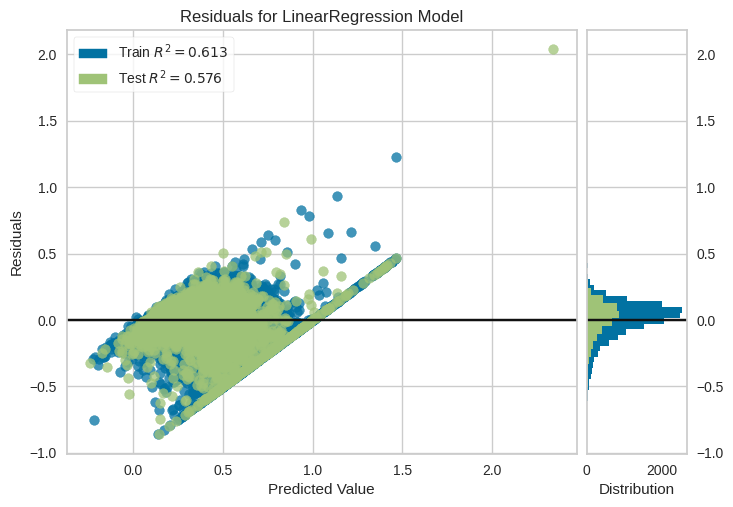

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [33]:
# otra manera
from yellowbrick.regressor import ResidualsPlot
visualizer = ResidualsPlot(regr)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.poof()

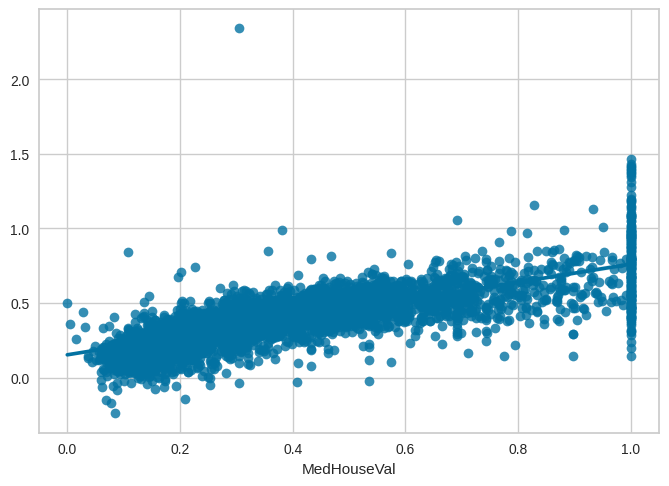

In [34]:
# Crear un gráfico de regresión
import seaborn as sns
sns.regplot(x=y_test, y=y_pred)
# Mostrar el gráfico de regresión
plt.show()

In [ ]:
#Alternativa

In [ ]:
regression_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression()) ])

In [ ]:
regression_pipeline.fit(X_train,y_train)

In [ ]:
y_pred = regression_pipeline.predict(X_test)

In [ ]:
y_pred

In [ ]:
from yellowbrick.regressor import ResidualsPlot
visualizer = ResidualsPlot(regression_pipeline)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.poof()